# 03 · 금리 위험을 재는 자 — 듀레이션 · DV01 · 볼록성 · 헤지비율

[![Colab에서 열기](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keerhee/pension-fund-strategy-and-performance/blob/main/W06_LDI%EC%99%80GBI/W06_M7_%EC%8B%A4%EC%8A%B5_Colab/03_%EB%93%80%EB%A0%88%EC%9D%B4%EC%85%98_DV01_%EB%B3%BC%EB%A1%9D%EC%84%B1.ipynb)

**W06 M7 LDI 강의본 단원 ③(29~36장)** 과 부록 B-1 · B-2(78 · 79장)를 재현합니다.

| 단계 | 강의 | 이 노트북에서 |
|---|---|---|
| 듀레이션 = 현재가치 가중 평균 만기 | 30장 | 20년 뒤 100: 5% 37.7 → 6% 31.2(−17%, 근사 −20%) · 3년 연금 비중 0.35 · 0.33 · 0.32 → D ≈ 1.97년 |
| 시소 · 전형적 기금 | 27 · 31 · 32 · 33장 | A 100(D 3) · L 80(D 20) · 갭 −17년 · 금리 −1%p → 자산 103 · 부채 96 · 잉여금 20 → 7(−65%) · FR 125 → 107% |
| DV01 | 34장 | 자산 0.03 · 부채 0.16 · 차이 −0.13/bp → 100bp면 −13 |
| 볼록성 · 테일러 | 35장 · B-1 · B-2 | 10년 뒤 100, 5% 연속복리: V 60.65 · D 10 · C 100 · +2%p 정확 −10.995 · 1차 −12.131 · 2차 −10.918 |
| 헤지비율 | 36장 | h = 자산 DV01 ÷ 부채 DV01 · 0.03 → 0.115 → 0.16 · h 19 → 72 → 100% · 금리 −1%p 후 잉여금 7 · 15.5 · 20 |

강의는 근사로 D(맥컬리)를 그대로 쓰고(정확히는 수정 듀레이션 D ÷ (1 + y)), 35장 · 부록 B는 연속복리로 계산합니다(이때는 둘이 같음).

### 0. 준비 — 이 셀부터 실행
한글 폰트(Colab은 나눔고딕 설치, 맥은 Pretendard), 강의 색(잉크 · 라임 · 티일 · 빨강), 강의본 숫자 확인 함수 `check()`를 준비합니다.
`check(이름, 계산값, 강의값, 허용오차)`는 계산이 강의본 숫자와 허용오차 안에서 맞는지 확인하고, 틀리면 멈춥니다(`assert`).
가정을 바꿔 실험할 때는 `FAST = True`로 두면 확인이 멈추지 않고 ✗로 표시만 합니다(M7 세트는 계산이 가벼워 속도 차이는 없음).

In [1]:
# ── 환경 준비: 한글 폰트 · 강의 색 · 확인 함수 (이 셀을 먼저 실행) ──
import sys, os, glob, math, time, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # 맥 numpy(Accelerate)의 거짓 경고 — 결과와 무관
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"):
    # Colab: 나눔 폰트 설치 (= !apt-get -qq install -y fonts-nanum) — 처음 한 번 10초 안팎
    subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null", shell=True)

def setup_korean_font():
    """로컬 맥은 Pretendard, Colab은 나눔고딕을 matplotlib에 등록한다(폰트 캐시 갱신과 같은 효과)."""
    files = (glob.glob(os.path.expanduser("~/Library/Fonts/Pretendard-*.otf"))
             + glob.glob("/Library/Fonts/Pretendard-*.otf")
             + glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"))
    for f in files:
        try:
            fm.fontManager.addfont(f)
        except Exception:
            pass
    names = {f.name for f in fm.fontManager.ttflist}
    for fam in ["Pretendard", "NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
        if fam in names:
            plt.rcParams["font.family"] = fam
            return fam
    return "(한글 폰트 없음 — 그래프 글자가 네모로 보이면 이 셀을 다시 실행)"

FONT = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

# 강의 색 — 잉크 · 라임 · 티일 · 빨강 (+ 보조 회색 · 아이보리 바탕)
INK, LIME, TEAL, RED = "#071A1D", "#B7F34A", "#0B6B68", "#C00000"
GRAY, IVORY, OLIVE = "#8A9496", "#F7F5F0", "#5E8C1A"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": IVORY,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#DDD8CC", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.axisbelow": True,
    "axes.prop_cycle": matplotlib.cycler(color=[TEAL, INK, RED, OLIVE, GRAY]),
})

# 빠른 모드 — M7 세트는 계산이 가벼워 FAST가 결과를 바꾸지 않는다. True면 확인(check)이 멈추지 않고 표시만 한다(숫자를 바꿔 실험할 때)
FAST = False

CHECKS = []
def check(label, value, lecture, tol, fmt=".4f", unit=""):
    """계산값을 강의본 숫자와 비교한다. 기본(재현) 모드에서는 허용오차를 넘으면 멈춘다(assert)."""
    ok = abs(value - lecture) <= tol + 1e-9      # 허용오차는 보통 강의 표기 자릿수의 반(반올림하면 같은 값)
    CHECKS.append((label, ok))
    print(f"{'✓' if ok else '✗'} {label}: 계산 {value:{fmt}}{unit} · 강의 {lecture:{fmt}}{unit} (허용 ±{tol:g})")
    if not FAST:
        assert ok, f"{label}: 계산 {value} · 강의 {lecture}"

print(f"Colab: {IN_COLAB} · 그래프 폰트: {FONT} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")

Colab: False · 그래프 폰트: Pretendard · numpy 2.0.2 · matplotlib 3.9.4


## 1. 한 번 받는 금액 — 듀레이션 = 만기 (강의 30장 ①)
20년 뒤 100을 받는 채권의 듀레이션은 20년. 핵심 공식 **ΔV / V ≈ −D · Δy** 에 넣으면 금리 +1%p에 약 −20%.
정확히 다시 할인하면 5% → 6%에서 37.7 → 31.2, 약 −17%입니다(차이는 볼록성 — 5절).

In [2]:
v5, v6 = 100 / 1.05**20, 100 / 1.06**20
print(f"5%: {v5:.1f} → 6%: {v6:.1f} · 정확 {v6 / v5 - 1:+.1%} · 근사 −D·Δy = −20 × 0.01 = −20%")
print(f"(수정 듀레이션 D/(1+y) = {20 / 1.05:.2f}년을 쓰면 근사 {-20 / 1.05:.1f}%)")
check("20년 뒤 100 · 5%", v5, 37.7, 0.05, ".1f")
check("20년 뒤 100 · 6%", v6, 31.2, 0.05, ".1f")
check("정확한 변화율 (%)", 100 * (v6 / v5 - 1), -17, 0.5, ".1f")

5%: 37.7 → 6%: 31.2 · 정확 -17.3% · 근사 −D·Δy = −20 × 0.01 = −20%
(수정 듀레이션 D/(1+y) = 19.05년을 쓰면 근사 -19.0%)
✓ 20년 뒤 100 · 5%: 계산 37.7 · 강의 37.7 (허용 ±0.05)
✓ 20년 뒤 100 · 6%: 계산 31.2 · 강의 31.2 (허용 ±0.05)
✓ 정확한 변화율 (%): 계산 -17.3 · 강의 -17.0 (허용 ±0.5)


## 2. 여러 번 받는 금액 — 현재가치 비중으로 평균 (강의 30장 ②)
D = Σ t · w_t, w_t = PV(CF_t) ÷ V. 01 노트북의 3년 연금(매년 30, 할인율 4%)이면?

In [3]:
def macaulay(cfs, r):
    t = np.arange(1, len(cfs) + 1)
    pv = np.asarray(cfs) / (1 + r) ** t
    w = pv / pv.sum()
    return float((t * w).sum()), w, float(pv.sum())

D3, w3, V3 = macaulay([30, 30, 30], 0.04)
print(f"V = {V3:.2f} · 비중 w = {np.round(w3, 2)} · D = 1×{w3[0]:.3f} + 2×{w3[1]:.3f} + 3×{w3[2]:.3f} = {D3:.2f}년")
for i, lec in enumerate([0.35, 0.33, 0.32]):
    check(f"{i + 1}년 뒤 비중", w3[i], lec, 0.005, ".3f")
check("3년 연금 듀레이션 (년)", D3, 1.97, 0.005, ".3f")

V = 83.25 · 비중 w = [0.35 0.33 0.32] · D = 1×0.346 + 2×0.333 + 3×0.320 = 1.97년
✓ 1년 뒤 비중: 계산 0.346 · 강의 0.350 (허용 ±0.005)
✓ 2년 뒤 비중: 계산 0.333 · 강의 0.330 (허용 ±0.005)
✓ 3년 뒤 비중: 계산 0.320 · 강의 0.320 (허용 ±0.005)
✓ 3년 연금 듀레이션 (년): 계산 1.974 · 강의 1.970 (허용 ±0.005)


## 3. 시소 — 전형적 기금 A 100(D_A 3) · L 80(D_L 20) (강의 31 · 32 · 33장)
갭 = D_A − D_L = −17년. 금리가 1%p 내리면 변화율 = −D × Δy → 자산 +3%, 부채 +20%.

In [4]:
A0, L0, DA, DL = 100.0, 80.0, 3.0, 20.0
dy = -0.01
A1, L1 = A0 * (1 - DA * dy), L0 * (1 - DL * dy)
S0, S1 = A0 - L0, A1 - L1
print(f"갭 D_A − D_L = {DA - DL:.0f}년")
print(f"금리 −1%p: 자산 {A0:.0f} → {A1:.0f} (+{-DA * dy:.0%}) · 부채 {L0:.0f} → {L1:.0f} (+{-DL * dy:.0%})")
print(f"잉여금 {S0:.0f} → {S1:.0f} ({S1 / S0 - 1:+.0%}) · 적립비율 {A0 / L0:.0%} → {A1 / L1:.1%}")
check("듀레이션 갭 (년)", DA - DL, -17, 0.5, ".1f")
check("금리 −1%p 후 자산", A1, 103, 0.5, ".1f")
check("금리 −1%p 후 부채", L1, 96, 0.5, ".1f")
check("금리 −1%p 후 잉여금", S1, 7, 0.5, ".1f")
check("잉여금 변화 (%)", 100 * (S1 / S0 - 1), -65, 0.5, ".1f")
check("금리 −1%p 후 적립비율 (%)", 100 * A1 / L1, 107, 0.5, ".1f")

갭 D_A − D_L = -17년
금리 −1%p: 자산 100 → 103 (+3%) · 부채 80 → 96 (+20%)
잉여금 20 → 7 (-65%) · 적립비율 125% → 107.3%
✓ 듀레이션 갭 (년): 계산 -17.0 · 강의 -17.0 (허용 ±0.5)
✓ 금리 −1%p 후 자산: 계산 103.0 · 강의 103.0 (허용 ±0.5)
✓ 금리 −1%p 후 부채: 계산 96.0 · 강의 96.0 (허용 ±0.5)
✓ 금리 −1%p 후 잉여금: 계산 7.0 · 강의 7.0 (허용 ±0.5)
✓ 잉여금 변화 (%): 계산 -65.0 · 강의 -65.0 (허용 ±0.5)
✓ 금리 −1%p 후 적립비율 (%): 계산 107.3 · 강의 107.0 (허용 ±0.5)


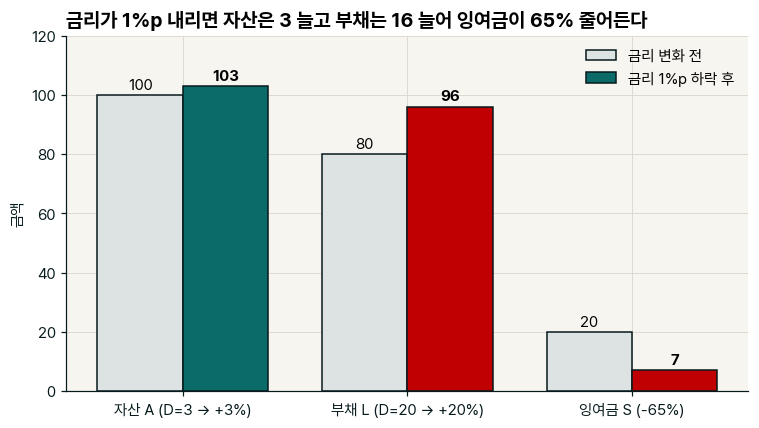

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(3); bw = 0.38
before, after = [A0, L0, S0], [A1, L1, S1]
ax.bar(x - bw / 2, before, bw, color="#DDE3E3", edgecolor=INK, label="금리 변화 전")
ax.bar(x + bw / 2, after, bw, color=[TEAL, RED, RED], edgecolor=INK, label="금리 1%p 하락 후")
for i in range(3):
    ax.text(i - bw / 2, before[i] + 2, f"{before[i]:.0f}", ha="center")
    ax.text(i + bw / 2, after[i] + 2, f"{after[i]:.0f}", ha="center", fontweight="bold")
ax.set_xticks(x, ["자산 A (D=3 → +3%)", "부채 L (D=20 → +20%)", f"잉여금 S ({S1 / S0 - 1:+.0%})"])
ax.set_ylim(0, 120); ax.set_ylabel("금액")
ax.set_title("금리가 1%p 내리면 자산은 3 늘고 부채는 16 늘어 잉여금이 65% 줄어든다")
ax.legend(loc="upper right")
plt.show()

## 4. DV01 — 금리 1bp에 몇 원 (강의 34장)
자산과 부채는 크기가 달라 %로는 바로 비교할 수 없습니다. **DV01 = D × V × 0.0001** 로 금액을 맞춰 봅니다.

In [6]:
dv01 = lambda D, V: D * V * 1e-4
DV01_A, DV01_L = dv01(DA, A0), dv01(DL, L0)
print(f"자산 DV01 = 3 × 100 × 0.0001 = {DV01_A:.2f} · 부채 DV01 = 20 × 80 × 0.0001 = {DV01_L:.2f} · 차이 {DV01_A - DV01_L:+.2f}")
print(f"금리가 100bp 내리면 잉여금 {100 * (DV01_A - DV01_L):+.0f} — 3절의 20 → 7과 같다")
check("자산 DV01", DV01_A, 0.03, 0.005, ".3f")
check("부채 DV01", DV01_L, 0.16, 0.005, ".3f")
check("DV01 차이", DV01_A - DV01_L, -0.13, 0.005, ".3f")
check("100bp 하락 시 잉여금 변화", 100 * (DV01_A - DV01_L), -13, 0.5, ".1f")

자산 DV01 = 3 × 100 × 0.0001 = 0.03 · 부채 DV01 = 20 × 80 × 0.0001 = 0.16 · 차이 -0.13
금리가 100bp 내리면 잉여금 -13 — 3절의 20 → 7과 같다
✓ 자산 DV01: 계산 0.030 · 강의 0.030 (허용 ±0.005)
✓ 부채 DV01: 계산 0.160 · 강의 0.160 (허용 ±0.005)
✓ DV01 차이: 계산 -0.130 · 강의 -0.130 (허용 ±0.005)
✓ 100bp 하락 시 잉여금 변화: 계산 -13.0 · 강의 -13.0 (허용 ±0.5)


## 5. 볼록성 — 기울기 + 휘어짐 (강의 35장 · 부록 B-1 · B-2)
**ΔV ≈ −D·V·Δy + ½·C·V·(Δy)²**. 10년 뒤 100을 주는 부채, y = 5%(연속복리): V = 100e^(−0.5) = 60.65, D = 10, C = D² = 100.
부록 B-1: V(y) = Σ CF_t e^(−yt) → V′ = −D·V, V″ = C·V. 아래에서 수치 미분으로도 확인합니다.

In [7]:
def V_bullet(y, face=100.0, t=10.0):
    return face * np.exp(-y * t)

y0 = 0.05
V0 = V_bullet(y0); D0, C0 = 10.0, 100.0
h = 1e-5
V1 = (V_bullet(y0 + h) - V_bullet(y0 - h)) / (2 * h)
V2 = (V_bullet(y0 + h) - 2 * V0 + V_bullet(y0 - h)) / h**2
print(f"V = {V0:.2f} · 수치 미분: V′ = {V1:.2f} (−D·V = {-D0 * V0:.2f}) · V″ = {V2:.1f} (C·V = {C0 * V0:.1f})")
check("V (10년 뒤 100, 5% 연속복리)", V0, 60.65, 0.005, ".2f")
check("B-1: V′ = −DV", V1, -D0 * V0, 0.01, ".2f")
check("B-1: V″ = CV", V2, C0 * V0, 0.5, ".1f")

LECT = {+0.01: (-5.772, -6.065, -5.762), -0.01: (6.379, 6.065, 6.369), +0.02: (-10.995, -12.131, -10.918)}
print(f"{'Δy':>6s} {'정확':>9s} {'1차만':>9s} {'1차+2차':>9s}")
for dy_, lec in LECT.items():
    exact = V_bullet(y0 + dy_) - V0
    first = -D0 * V0 * dy_
    second = first + 0.5 * C0 * V0 * dy_**2
    print(f"{dy_ * 100:+5.0f}%p {exact:9.3f} {first:9.3f} {second:9.3f}")
    for lab, v, l in zip(["정확", "1차만", "1차+2차"], [exact, first, second], lec):
        check(f"Δy {dy_ * 100:+.0f}%p {lab}", v, l, 0.0005, ".3f")

V = 60.65 · 수치 미분: V′ = -606.53 (−D·V = -606.53) · V″ = 6065.3 (C·V = 6065.3)
✓ V (10년 뒤 100, 5% 연속복리): 계산 60.65 · 강의 60.65 (허용 ±0.005)
✓ B-1: V′ = −DV: 계산 -606.53 · 강의 -606.53 (허용 ±0.01)
✓ B-1: V″ = CV: 계산 6065.3 · 강의 6065.3 (허용 ±0.5)
    Δy        정확       1차만     1차+2차
   +1%p    -5.772    -6.065    -5.762
✓ Δy +1%p 정확: 계산 -5.772 · 강의 -5.772 (허용 ±0.0005)
✓ Δy +1%p 1차만: 계산 -6.065 · 강의 -6.065 (허용 ±0.0005)
✓ Δy +1%p 1차+2차: 계산 -5.762 · 강의 -5.762 (허용 ±0.0005)
   -1%p     6.379     6.065     6.369
✓ Δy -1%p 정확: 계산 6.379 · 강의 6.379 (허용 ±0.0005)
✓ Δy -1%p 1차만: 계산 6.065 · 강의 6.065 (허용 ±0.0005)
✓ Δy -1%p 1차+2차: 계산 6.369 · 강의 6.369 (허용 ±0.0005)
   +2%p   -10.995   -12.131   -10.918
✓ Δy +2%p 정확: 계산 -10.995 · 강의 -10.995 (허용 ±0.0005)
✓ Δy +2%p 1차만: 계산 -12.131 · 강의 -12.131 (허용 ±0.0005)
✓ Δy +2%p 1차+2차: 계산 -10.918 · 강의 -10.918 (허용 ±0.0005)


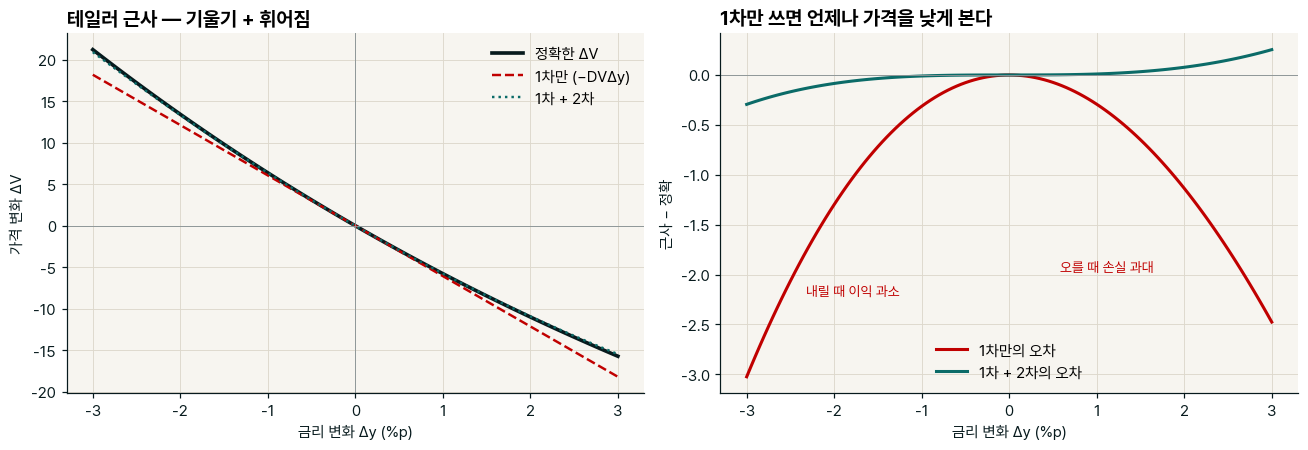

In [8]:
dys = np.linspace(-0.03, 0.03, 121)
exact = V_bullet(y0 + dys) - V0
first = -D0 * V0 * dys
second = first + 0.5 * C0 * V0 * dys**2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.plot(dys * 100, exact, color=INK, lw=2.4, label="정확한 ΔV")
ax1.plot(dys * 100, first, color=RED, lw=1.6, ls="--", label="1차만 (−DVΔy)")
ax1.plot(dys * 100, second, color=TEAL, lw=1.6, ls=":", label="1차 + 2차")
ax1.axhline(0, color=GRAY, lw=0.6); ax1.axvline(0, color=GRAY, lw=0.6)
ax1.set_xlabel("금리 변화 Δy (%p)"); ax1.set_ylabel("가격 변화 ΔV"); ax1.legend()
ax1.set_title("테일러 근사 — 기울기 + 휘어짐")
ax2.plot(dys * 100, first - exact, color=RED, lw=2, label="1차만의 오차")
ax2.plot(dys * 100, second - exact, color=TEAL, lw=2, label="1차 + 2차의 오차")
ax2.axhline(0, color=GRAY, lw=0.6)
ax2.annotate("오를 때 손실 과대", (2.5, (first - exact)[-10]), textcoords="offset points", xytext=(-110, -10), color=RED, fontsize=9)
ax2.annotate("내릴 때 이익 과소", (-2.5, (first - exact)[10]), textcoords="offset points", xytext=(10, -10), color=RED, fontsize=9)
ax2.set_xlabel("금리 변화 Δy (%p)"); ax2.set_ylabel("근사 − 정확"); ax2.legend(loc="lower center")
ax2.set_title("1차만 쓰면 언제나 가격을 낮게 본다")
fig.tight_layout(); plt.show()

**부록 B-2 — 볼록성 = 듀레이션² + 지급 시점의 분산.** C = Σ t²w_t = D² + Σ w_t(t − D)².
같은 듀레이션이면 현금흐름이 시간상 더 퍼질수록 C가 큽니다. 불릿(10년 한 번)은 분산 0 → C = 100, 바벨(5년 + 15년, 현재가치 반반)은 C = 10² + 5² = 125.

In [9]:
def dur_conv(times, pvs):
    t, w = np.asarray(times, float), np.asarray(pvs, float) / np.sum(pvs)
    D = float((t * w).sum()); Cx = float((t**2 * w).sum())
    return D, Cx, float((w * (t - D) ** 2).sum())

for name, times, pvs in [("불릿 10년", [10], [1]), ("바벨 5년 + 15년 (반반)", [5, 15], [0.5, 0.5])]:
    D_, C_, var_ = dur_conv(times, pvs)
    print(f"{name:20s} D = {D_:.0f} · C = Σt²w = {C_:.0f} = D² {D_**2:.0f} + 분산 {var_:.0f}")
check("B-2 불릿 C", dur_conv([10], [1])[1], 100, 0.5, ".0f")
check("B-2 바벨 C", dur_conv([5, 15], [0.5, 0.5])[1], 125, 0.5, ".0f")

불릿 10년               D = 10 · C = Σt²w = 100 = D² 100 + 분산 0
바벨 5년 + 15년 (반반)     D = 10 · C = Σt²w = 125 = D² 100 + 분산 25
✓ B-2 불릿 C: 계산 100 · 강의 100 (허용 ±0.5)
✓ B-2 바벨 C: 계산 125 · 강의 125 (허용 ±0.5)


## 6. 헤지비율 h = 자산 DV01 ÷ 부채 DV01 (강의 36장)
h = 100%면 금리가 움직여도 잉여금이 거의 변하지 않습니다. 같은 기금(A 100 · L 80)의 세 포트폴리오:
1. 지금 — 자산 전부 D = 3
2. 50을 30년물(D 20)로, 나머지 50은 D 3
3. 80은 30년물(D 20) + 20은 주식(D 0)

In [10]:
PORTS = {"지금 (전부 D=3)": [(100, 3)],
         "50을 30년물로": [(50, 20), (50, 3)],
         "80은 30년물 + 20은 주식": [(80, 20), (20, 0)]}
LECT_DV01, LECT_S = [0.03, 0.115, 0.16], [7, 15.5, 20]
H, S_after = [], []
for (name, legs), ldv, ls in zip(PORTS.items(), LECT_DV01, LECT_S):
    dvA = sum(dv01(D, V) for V, D in legs)
    hr = dvA / DV01_L
    S_new = (A0 + 100 * dvA) - L1                 # 금리 −1%p(= −100bp): 자산 +100 × DV01, 부채 80 → 96
    H.append(hr); S_after.append(S_new)
    print(f"{name:22s} 자산 DV01 {dvA:.3f} · h = {hr:.0%} · 금리 −1%p 후 잉여금 {S_new:.1f}")
    check(f"{name} 자산 DV01", dvA, ldv, 0.0005, ".3f")
    check(f"{name} 금리 −1%p 후 잉여금", S_new, ls, 0.05, ".1f")
check("지금 h (%)", 100 * H[0], 19, 0.5, ".1f")
check("50을 30년물로 h (%)", 100 * H[1], 72, 0.5, ".1f")
check("80은 30년물 h (%)", 100 * H[2], 100, 0.5, ".1f")

지금 (전부 D=3)            자산 DV01 0.030 · h = 19% · 금리 −1%p 후 잉여금 7.0
✓ 지금 (전부 D=3) 자산 DV01: 계산 0.030 · 강의 0.030 (허용 ±0.0005)
✓ 지금 (전부 D=3) 금리 −1%p 후 잉여금: 계산 7.0 · 강의 7.0 (허용 ±0.05)
50을 30년물로              자산 DV01 0.115 · h = 72% · 금리 −1%p 후 잉여금 15.5
✓ 50을 30년물로 자산 DV01: 계산 0.115 · 강의 0.115 (허용 ±0.0005)
✓ 50을 30년물로 금리 −1%p 후 잉여금: 계산 15.5 · 강의 15.5 (허용 ±0.05)
80은 30년물 + 20은 주식      자산 DV01 0.160 · h = 100% · 금리 −1%p 후 잉여금 20.0
✓ 80은 30년물 + 20은 주식 자산 DV01: 계산 0.160 · 강의 0.160 (허용 ±0.0005)
✓ 80은 30년물 + 20은 주식 금리 −1%p 후 잉여금: 계산 20.0 · 강의 20.0 (허용 ±0.05)
✓ 지금 h (%): 계산 18.8 · 강의 19.0 (허용 ±0.5)
✓ 50을 30년물로 h (%): 계산 71.9 · 강의 72.0 (허용 ±0.5)
✓ 80은 30년물 h (%): 계산 100.0 · 강의 100.0 (허용 ±0.5)


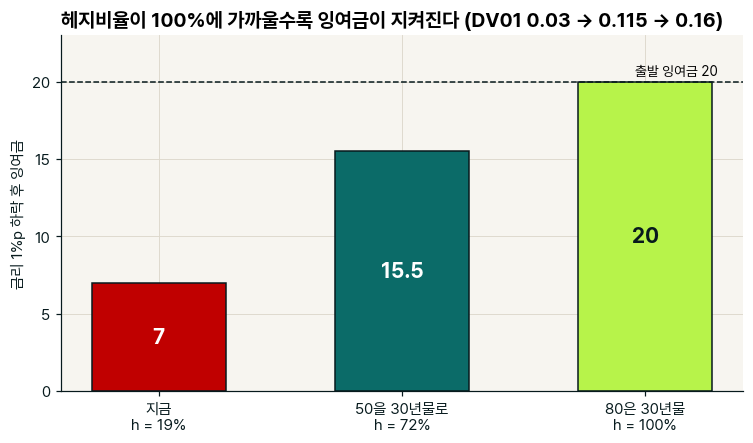

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.2))
labels = [f"지금\nh = {H[0]:.0%}", f"50을 30년물로\nh = {H[1]:.0%}", f"80은 30년물\nh = {H[2]:.0%}"]
bars = ax.bar(labels, S_after, 0.55, color=[RED, TEAL, LIME], edgecolor=INK)
for b, v in zip(bars, S_after):
    ax.text(b.get_x() + b.get_width() / 2, v / 2, f"{v:g}", ha="center", va="center", fontsize=14, fontweight="bold",
            color="white" if b.get_facecolor()[:3] != matplotlib.colors.to_rgb(LIME) else INK)
ax.axhline(S0, color=INK, ls="--", lw=1); ax.text(2.3, S0 + 0.4, "출발 잉여금 20", ha="right", fontsize=9)
ax.set_ylim(0, 23); ax.set_ylabel("금리 1%p 하락 후 잉여금")
ax.set_title("헤지비율이 100%에 가까울수록 잉여금이 지켜진다 (DV01 0.03 → 0.115 → 0.16)")
plt.show()

**국민연금(강의 36장 · 07 노트북)** — 원화 자산 듀레이션 0.85년 vs 순부채 듀레이션 35년 → 갭 약 −34년, 헤지 2.1%(현 보유) → 3%(2027 목표 비중 이행 시).
같은 h 식으로 계산한 값이며, 계산 과정은 07 노트북에서 재현합니다.

**그래프 — 헤지비율 h에 따라 금리 변화가 잉여금을 얼마나 움직이나.** 자산이 h만큼 부채 DV01을 따라가면 ΔS ≈ −(1 − h)·DV01_L·Δy(bp).

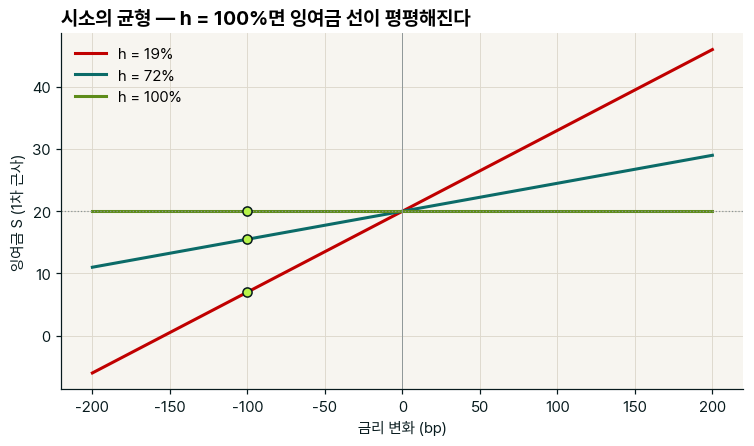

In [12]:
dys_bp = np.linspace(-200, 200, 81)
fig, ax = plt.subplots(figsize=(8, 4.2))
for hh, c in [(H[0], RED), (H[1], TEAL), (H[2], OLIVE)]:
    dvA = hh * DV01_L
    A_ = A0 * (1 - (dvA / (A0 * 1e-4)) * dys_bp / 1e4)
    L_ = L0 * (1 - DL * dys_bp / 1e4)
    ax.plot(dys_bp, A_ - L_, color=c, lw=2, label=f"h = {hh:.0%}")
ax.axhline(S0, color=GRAY, lw=0.8, ls=":"); ax.axvline(0, color=GRAY, lw=0.6)
ax.scatter([-100] * 3, S_after, color=LIME, edgecolor=INK, zorder=5)
ax.set_xlabel("금리 변화 (bp)"); ax.set_ylabel("잉여금 S (1차 근사)")
ax.set_title("시소의 균형 — h = 100%면 잉여금 선이 평평해진다")
ax.legend()
plt.show()

## 7. 정리
- 금리 위험은 **듀레이션 갭**에서 옵니다. 전형적 기금 −17년, 국민연금 약 −34년.
- DV01로 금액을 맞추면 헤지비율 h가 나오고, h = 100%는 다음 단원(04)의 Redington 조건 2와 같은 말입니다.
- 1차 근사는 큰 금리 변화에서 틀립니다 — 휘어짐(볼록성)이 Redington 조건 3의 근거입니다.

---
### 확인 결과 요약
이 노트북에서 강의본 숫자와 비교한 항목을 모아 봅니다. 모두 ✓이면 강의본 숫자를 그대로 재현한 것입니다.

In [13]:
# ── 확인 결과 요약 ──
n_ok = sum(ok for _, ok in CHECKS)
print(f"강의본 숫자 확인 {n_ok} / {len(CHECKS)} 통과" + (" — 빠른 모드라 일부 차이는 정상" if FAST else ""))
for label, ok in CHECKS:
    if not ok:
        print("  ✗", label)

강의본 숫자 확인 40 / 40 통과


---
## 바꿔 보기 (연습 문제)

1. 3년 연금의 할인율을 4% → 8%로 올리면 듀레이션은 어떻게 바뀌나? 왜 짧아지는지 비중 w로 설명하라.
2. 부채 듀레이션이 20 → 25년이면(같은 A 100 · L 80) 금리 −1%p 후 잉여금과 헤지비율 h(지금 포트폴리오)는?
3. 30년 국채(D 20) 대신 50년 국채(D 30)로 h = 100%를 맞추려면 얼마가 필요한가? (필요 금액 = 0.16 ÷ (D × 0.0001))

아래 빈 셀에서 직접 해 보세요. 위 셀의 함수를 그대로 불러 쓰면 됩니다.

In [14]:
# 여기에 직접 해 보기

In [15]:
# 여기에 직접 해 보기

In [16]:
# 여기에 직접 해 보기